In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_pure_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 10
T = 23/12 #NOTE: changed!
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)
# # Source
# m1 = 1e6
# m2 = 1e1
# a = 0.7
# p0 = 9
# e0 = 0.4
# xI0 = 1.0
# dist = 4.5
# qS = np.pi
# phiS = 0.
# qK = 0.
# phiK = 0.
# Phi_phi0 = 0.4
# Phi_theta0 = 0.0
# Phi_r0 = 0.5    

# Mojito light EMRI_G
# m1 = 6.72e5
# m2 = 9.84e1
# a = 0.5
# p0 = 15.7117
# e0 = 0.7440
# xI0 = 1.0
# dist = 4.755
# qS = 0.5906
# phiS = 3.5808
# qK = 1.1707
# phiK = 3.8495
# Phi_phi0 = 3.1940
# Phi_theta0 = 3.3780
# Phi_r0 = 0.6038

def icrs_to_ecliptic(qK_icrs, phiK_icrs, eps_deg=23.43929111):
    """
    Convert a sky direction (colatitude, longitude) from the ICRS/equatorial
    frame (qK = pi/2 - dec, phiK = ra) to the ecliptic frame (SSB frame used
    by the LISA response, is_ecliptic_latitude=False convention) via the
    standard equatorial<->ecliptic rotation with J2000 mean obliquity eps.
    """
    dec = np.pi / 2 - qK_icrs
    ra = phiK_icrs
    eps = np.deg2rad(eps_deg)

    sin_beta = np.sin(dec) * np.cos(eps) - np.cos(dec) * np.sin(ra) * np.sin(eps)
    beta = np.arcsin(sin_beta)

    y = np.cos(dec) * np.sin(ra) * np.cos(eps) + np.sin(dec) * np.sin(eps)
    x = np.cos(dec) * np.cos(ra)
    lam = np.arctan2(y, x) % (2 * np.pi)

    qK_ecl = np.pi / 2 - beta
    phiK_ecl = lam
    return qK_ecl, phiK_ecl

# Mojito light EMRI_C
m1 = 3.54e6
m2 = 8.01e1
a = 0.950
p0 = 7.3890
e0 = 0.3160
xI0 = 1.0000
dist = 4.858
qS = 2.0420
phiS = 5.7873
qK, phiK = icrs_to_ecliptic(1.6633, 1.7431)  # catalog qK/phiK are in ICRS, convert to ecliptic
Phi_phi0 = 2.4044
Phi_theta0 = 0.2850
Phi_r0 = 0.9743

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, np.cos(qS), phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    """
    Coherent (pure) f-statistic (loglike_pure_noise.LogLike), row-by-row.

    Calls LogLike.__call__ once per row instead of the batched
    log_density_batch path.
    """
    params = np.asarray(params)
    B = params.shape[0]
    logl = np.empty(B, dtype=np.float64)
    for b in range(B):
        logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = params[b]
        qS_i = np.arccos(cosqS_i)
        theta = [
            10**logm1, 10**logm2, a_i, p0_i, e0_i,
            xI0, dist, qS_i, phiS_i, qK, phiK,
            Phi_phi0, Phi_theta0, Phi_r0,
        ]
        try:
            logl[b] = loglike_obj(theta)
        except Exception:
            logl[b] = -np.inf
    return logl


def prior_transform(u):
    # from stage1_anneal
    # logm1lim = [5.82507, 5.82762]
    # logm2lim = [1.99252, 1.99310]
    # alim = [0.49334, 0.50078]
    # p0lim = [15.70599, 15.75367]
    # e0lim = [0.74388, 0.74418]
    # cosqSlim = [0.79926, 0.86149]    
    # phiSlim = [3.48384, 3.66905]

    # logm1lim = [5.82663, 5.82804]
    # logm2lim = [1.99282, 1.99316]
    # alim =  [0.49785, 0.50193]
    # p0lim = [15.69935, 15.72547]
    # e0lim = [0.74392, 0.74409]
    # cosqSlim = [0.80724, 0.85206]
    # phiSlim =  [3.49931, 3.62436]

    # emri c, matches paris5_lhs_box.py box (from stage1_anneal_s12)
    logm1lim = [6.54900, 6.54901]
    logm2lim = [1.90363, 1.90364]
    alim =  [0.95000, 0.95001]
    p0lim = [7.38894, 7.38903]
    e0lim = [0.31599, 0.31601]
    cosqSlim = [-0.47014, -0.44492]
    phiSlim =  [5.77627, 5.80239]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (cosqSlim[1] - cosqSlim[0]) * u[:, 5] + cosqSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    # emri c, matches paris5_lhs_box.py box (from stage1_anneal_s12)
    logm1lim = [6.54900, 6.54901]
    logm2lim = [1.90363, 1.90364]
    alim =  [0.95000, 0.95001]
    p0lim = [7.38894, 7.38903]
    e0lim = [0.31599, 0.31601]
    cosqSlim = [-0.47014, -0.44492]
    phiSlim =  [5.77627, 5.80239]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u

Using dt=10s, T=1.9166666666666667yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_c/stage2_f_1e4_ext/'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [4]:
sampler.now_covariances

[array([[ 4.84125208e-02,  2.89375574e-02,  4.35457116e-02,
         -4.74099731e-02, -2.87854422e-02, -9.88062251e-06,
         -2.13612751e-03],
        [ 2.89375574e-02,  6.79416783e-02,  4.16145328e-02,
         -6.93210246e-03, -4.53151965e-02, -3.67117321e-03,
         -7.06076866e-03],
        [ 4.35457116e-02,  4.16145328e-02,  8.06249251e-02,
         -4.55122083e-02, -1.52786793e-02, -1.47793104e-04,
          1.17637481e-03],
        [-4.74099731e-02, -6.93210246e-03, -4.55122083e-02,
          5.80318574e-02,  1.08951825e-02, -1.08749504e-03,
         -1.30377990e-03],
        [-2.87854422e-02, -4.53151965e-02, -1.52786793e-02,
          1.08951825e-02,  4.57109794e-02, -1.84183996e-04,
          4.19089640e-03],
        [-9.88062251e-06, -3.67117321e-03, -1.47793104e-04,
         -1.08749504e-03, -1.84183996e-04,  1.43493076e-01,
          3.08626922e-03],
        [-2.13612751e-03, -7.06076866e-03,  1.17637481e-03,
         -1.30377990e-03,  4.19089640e-03,  3.08626922e-03

In [5]:
len(sampler.now_covariances)

1

In [6]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 6.54900544,  1.90363192,  0.95000233,  7.38897171,  0.31600117,
        -0.4695093 ,  5.80237301]])

In [7]:
param_true

[6.549003262025788,
 1.9036325160842376,
 0.95,
 7.389,
 0.316,
 -0.45395911390155774,
 5.7873]

In [8]:
log_density(maxld_pt1)

array([118.05507982])

In [9]:
log_density([param_true])

array([115.77939715])

In [10]:
param_ranges = [(6.54900,  6.54901),
                (1.90363,  1.90364),
                (0.95000,  0.95001),
                (7.38894,  7.38903),
                (0.31599,  0.31601),
                (-0.47014, -0.44492),
                (5.77627, 5.80239)
                ]
param_ranges

[(6.549, 6.54901),
 (1.90363, 1.90364),
 (0.95, 0.95001),
 (7.38894, 7.38903),
 (0.31599, 0.31601),
 (-0.47014, -0.44492),
 (5.77627, 5.80239)]

In [11]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[6.549003262025788,
 1.9036325160842376,
 0.95,
 7.389,
 0.316,
 -0.45395911390155774,
 5.7873]

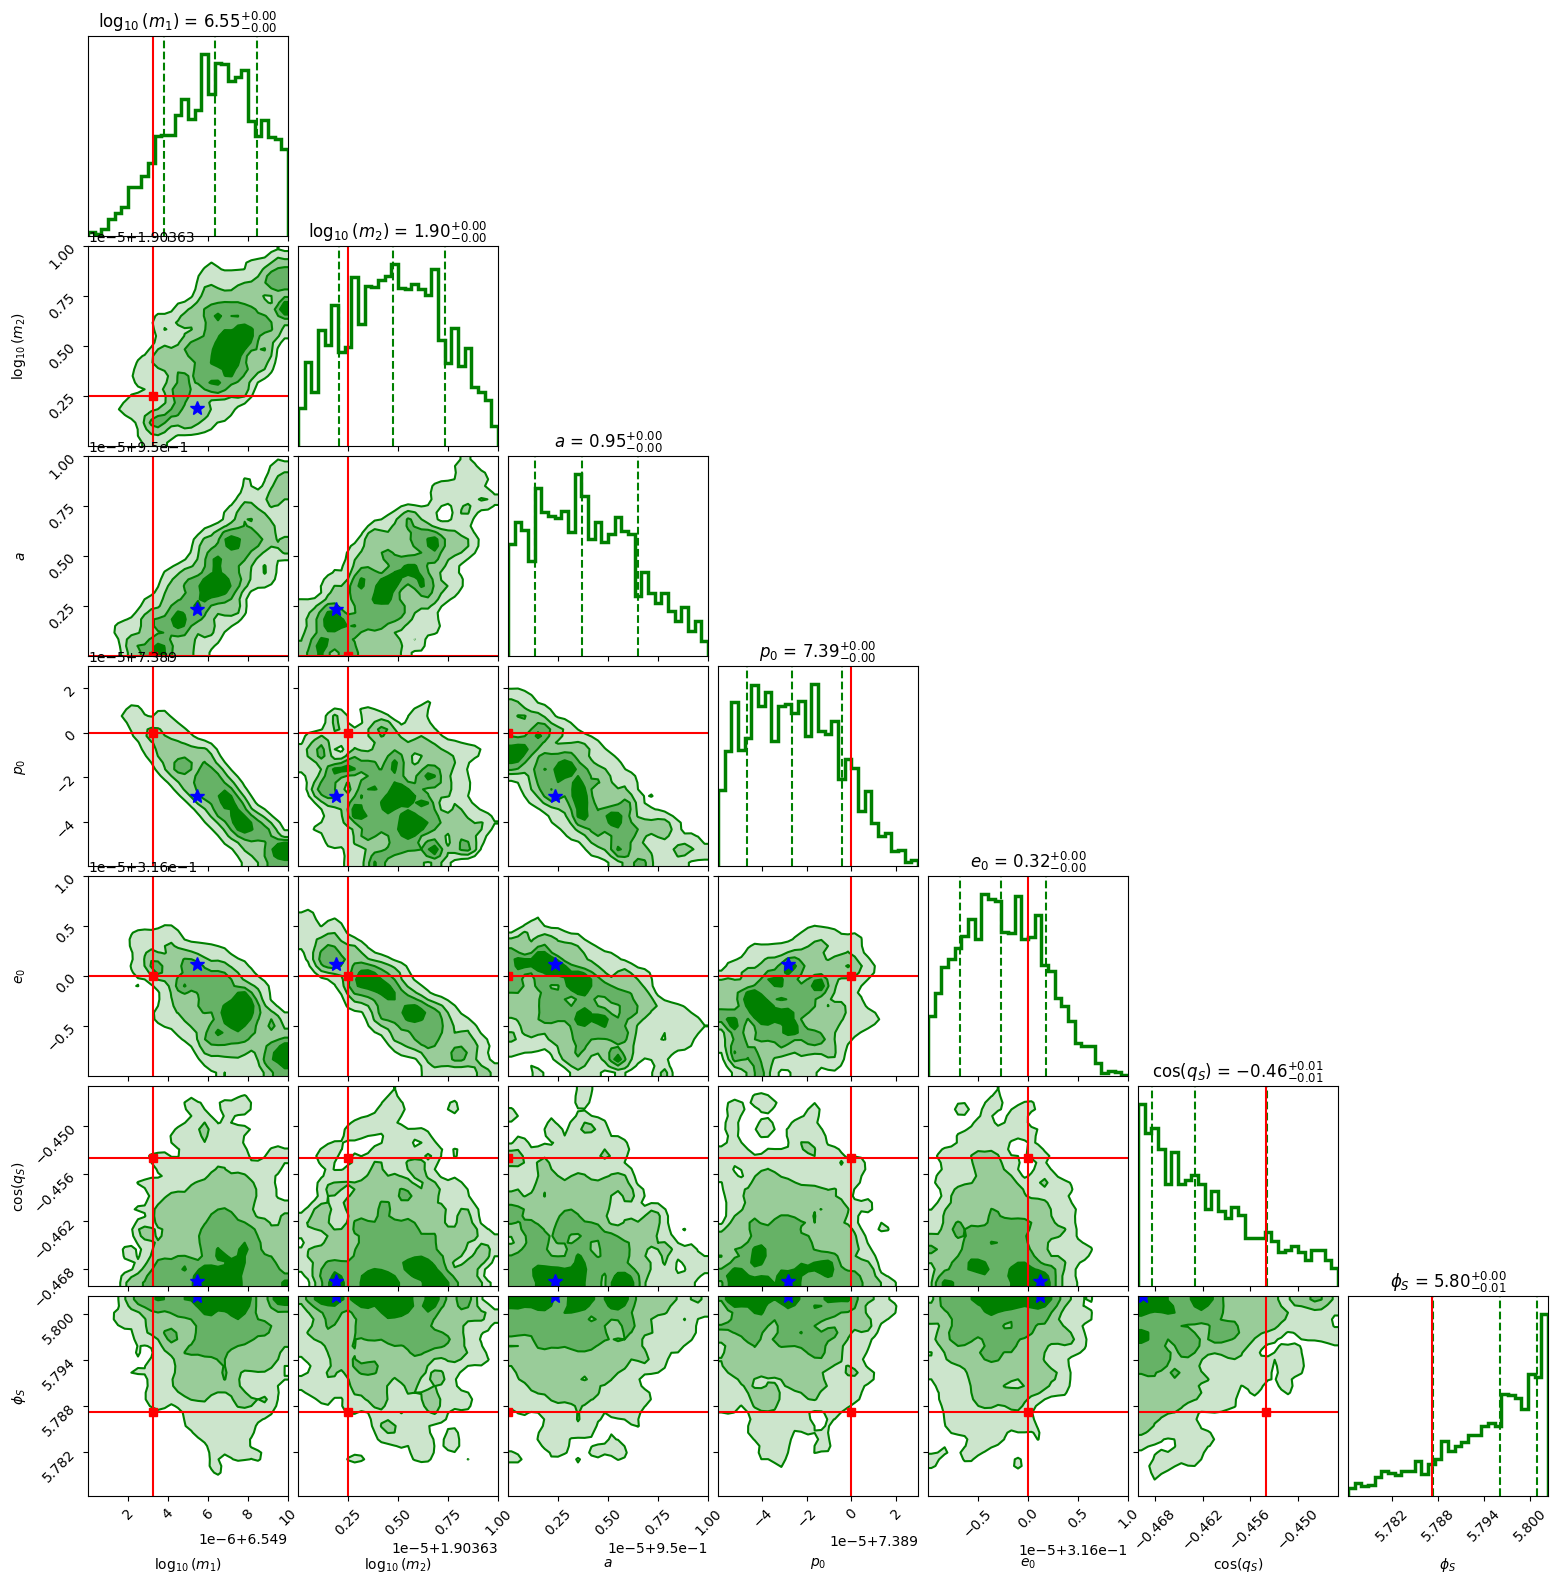

In [12]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)


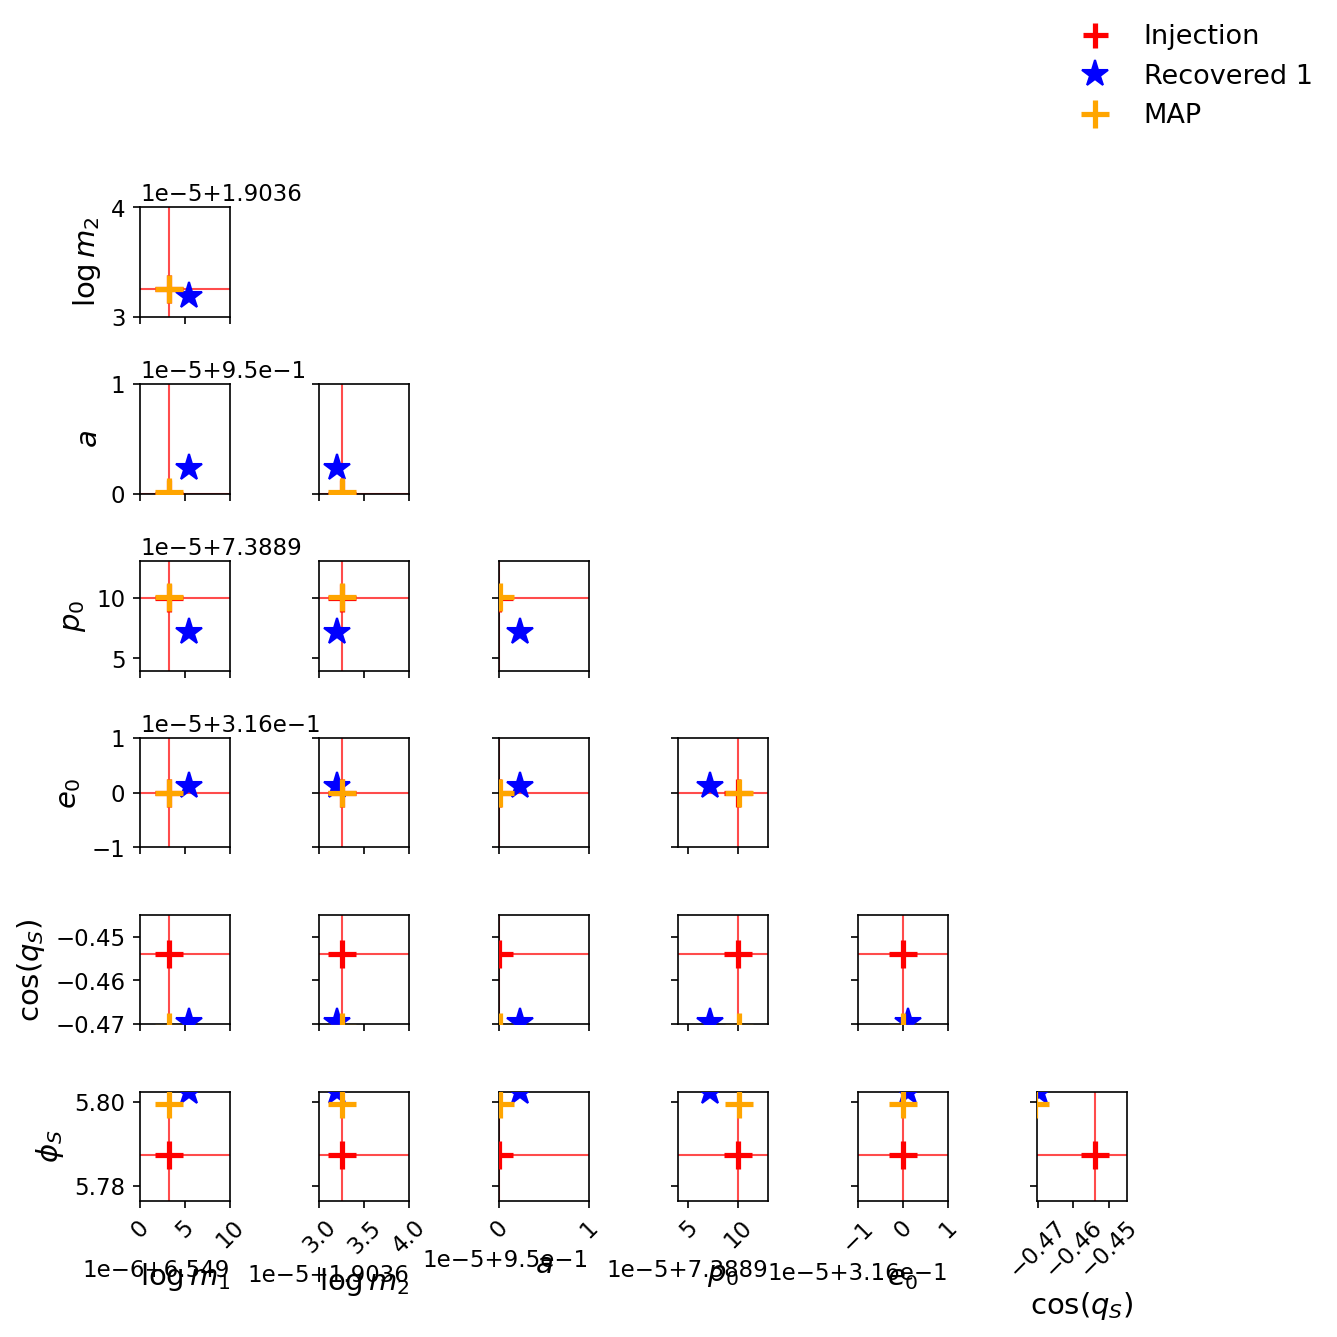

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$\cos(q_S)$', r'$\phi_S$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# NM-recovered point from map_mojito_light_emri_c_7d.py, same 7-dim subspace
nm_data   = np.load('/scratch/e1498138/map_mojito_light_c_7d_pure_seed42.npz')
maxld_pt2 = np.asarray(nm_data['x_map']).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP points
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)
        ax.plot(maxld_pt2[j], maxld_pt2[i], '+', color='orange',
                ms=13, mew=2.5, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',    marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue',   marker='*', ls='', ms=13,          label='Recovered 1'),
    Line2D([0], [0], color='orange', marker='+', ls='', ms=13, mew=2.5, label='MAP')
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()  

# connection plot to proc 1

In [14]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 6.54900544,  1.90363192,  0.95000233,  7.38897171,  0.31600117,
        -0.4695093 ,  5.80237301]])

In [15]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [16]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [17]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


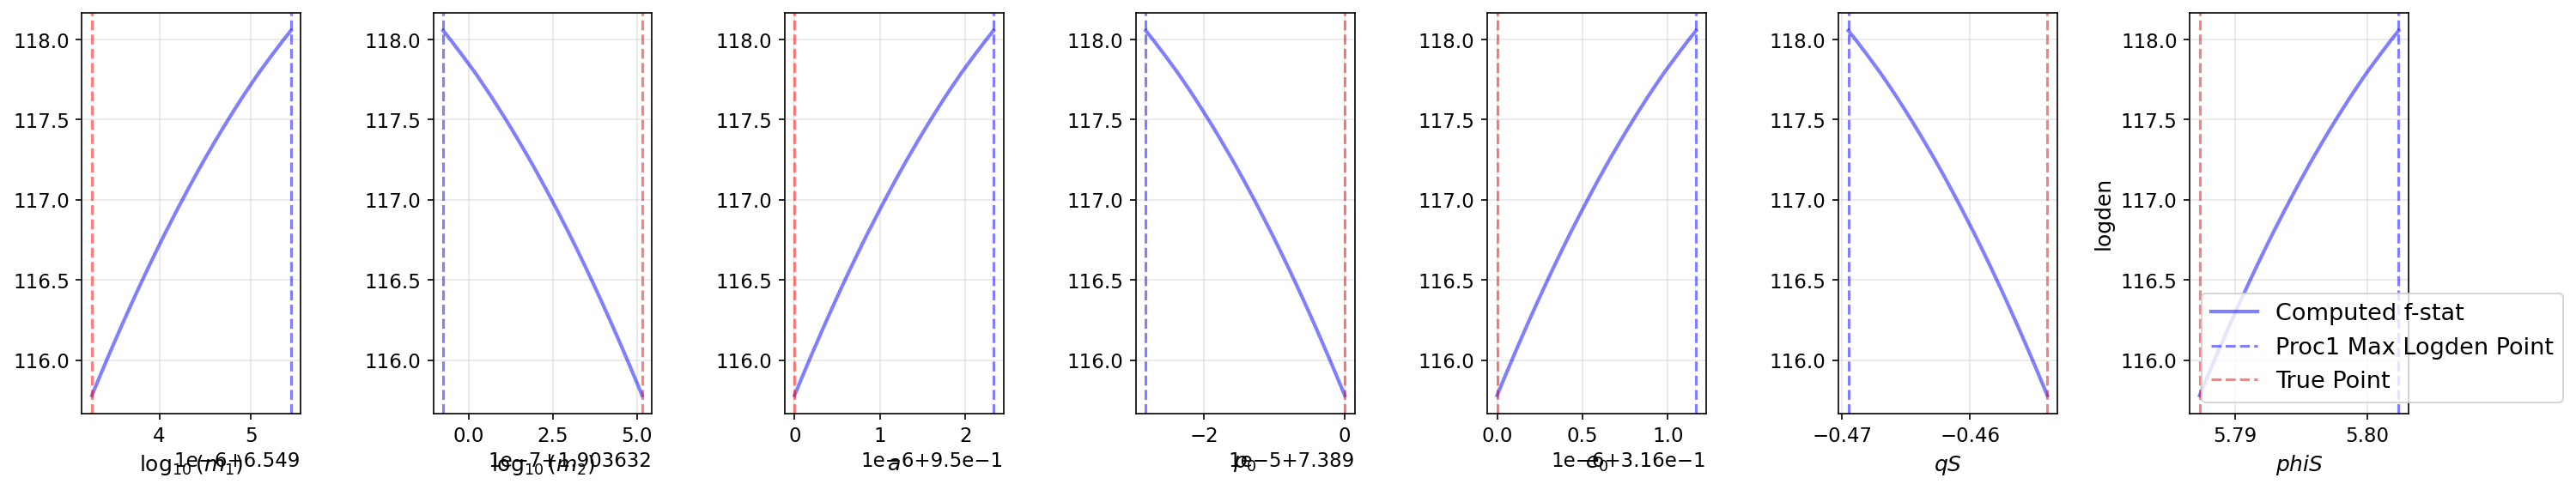

In [18]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [19]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [20]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [21]:
logden_tm = log_density(line_points_logm1.T)


In [22]:
line_points_logm1.T[np.argmax(logden_tm)]

array([ 6.54900749,  1.90363137,  0.95000452,  7.38894506,  0.31600226,
       -0.48415786,  5.81657206])

In [23]:
log_density(line_points_logm1.T[np.argmax(logden_tm)].reshape(1, -1))

NameError: name 'logden_tm' is not defined

In [23]:
def loglikelihood(params_row):
    """params_row: [log10(m1), log10(m2), a, p0, e0, cos(qS), phiS].
    Standard Gaussian log-likelihood, up to a theta-independent additive constant:
        lnL(theta) = -0.5 * <d - h(theta) | d - h(theta)>
    Uses loglike_obj.signal_fft (the seed=42 noisy data already built above) and
    the full (unrestricted-mode) waveform -- no mode selection, no f-stat penalty.
    """
    logm1, logm2, a, p0, e0, cosqS, phiS = params_row
    qS = np.arccos(cosqS)
    theta = [10**logm1, 10**logm2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
             Phi_phi0, Phi_theta0, Phi_r0]
    h = gwf.xp.array(waveform_response(*theta, T=T, dt=dt))
    h_fft = gwf.freq_wave(h)
    r_fft = loglike_obj.signal_fft - h_fft
    chi2 = float(gwf.inner(r_fft, r_fft))
    return -0.5 * chi2

def loglikelihood_ratio(params_row):
    """ln Lambda(theta) = <d|h(theta)> - 0.5*<h(theta)|h(theta)>, against
    the noisy data (loglike_obj.signal_fft, seed=42 already loaded above)."""
    logm1, logm2, a, p0, e0, cosqS, phiS = params_row
    qS = np.arccos(cosqS)
    theta = [10**logm1, 10**logm2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
            Phi_phi0, Phi_theta0, Phi_r0]
    h = gwf.xp.array(waveform_response(*theta, T=T, dt=dt))
    h_fft = gwf.freq_wave(h)
    d_dot_h = float(gwf.inner(loglike_obj.signal_fft, h_fft, return_complex=False))
    h_dot_h = float(gwf.inner(h_fft, h_fft))
    return d_dot_h - 0.5 * h_dot_h

In [24]:
n_points = line_points_logm1.shape[1]
lnL_tm = np.array([loglikelihood(line_points_logm1[:, i]) for i in range(n_points)])

In [25]:
maxld_pt2

array([ 6.5490032 ,  1.90363256,  0.95000013,  7.3890003 ,  0.316     ,
       -0.47067891,  5.79959081])

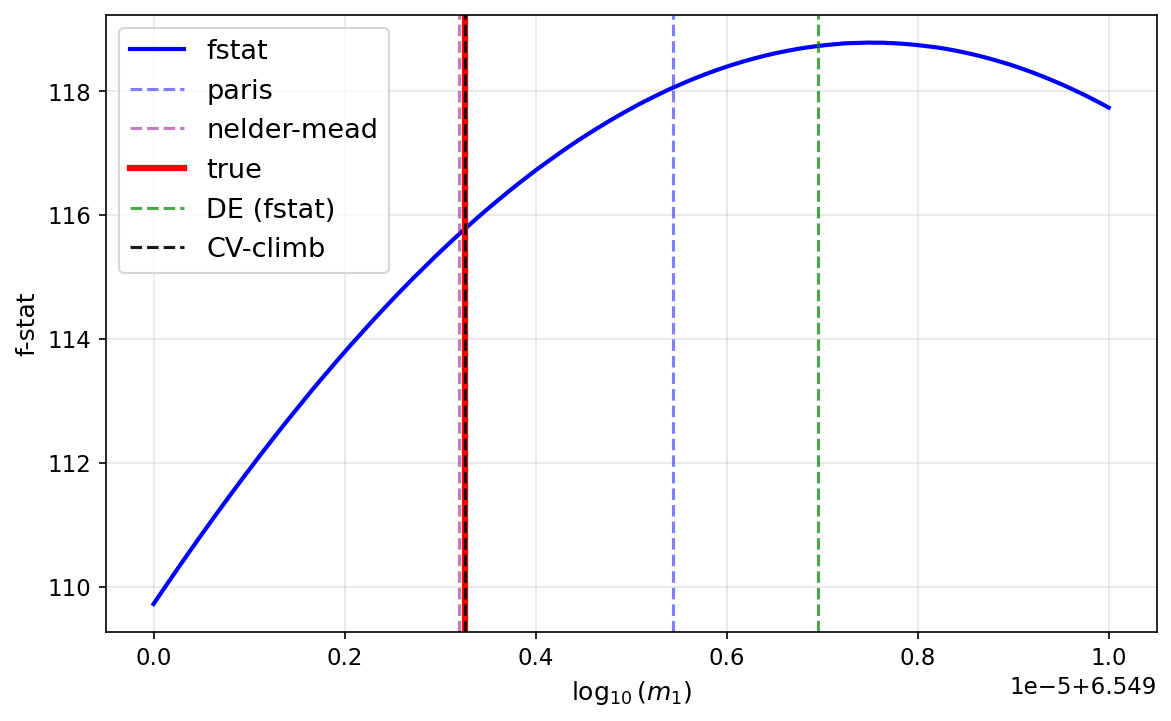

In [25]:
import json
import numpy as np

# DE of fstat
GLOBAL_MAP = np.array([6.54900696, 1.9036349, 0.95000461, 7.38896623, 0.31599714, -0.47013992, 5.80238988])

# CV climb result
with open('/nfs/home/svu/e1498138/EMRI_CV_bias/src/EMRI/results_emri_c_noise_seed42_T23mth_from_primary_logcos.json') as f:
    cv_result = json.load(f)
refined = np.array(cv_result['refined'])   # [log10m1, log10m2, a, p0, e0, cos(qS), phiS]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='fstat')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='paris')
ax.axvline(maxld_pt2[0],         color='purple', linestyle='--', alpha=0.5, label='nelder-mead')
ax.axvline(param_true[0],        color='red',  linewidth=3, label='true')

ax.axvline(GLOBAL_MAP[0], color='green', linestyle='--', alpha=0.7, label='DE (fstat)')
ax.axvline(refined[0],    color='black', linestyle='--',  alpha=0.9, linewidth=1.5, label='CV-climb')

ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('f-stat', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

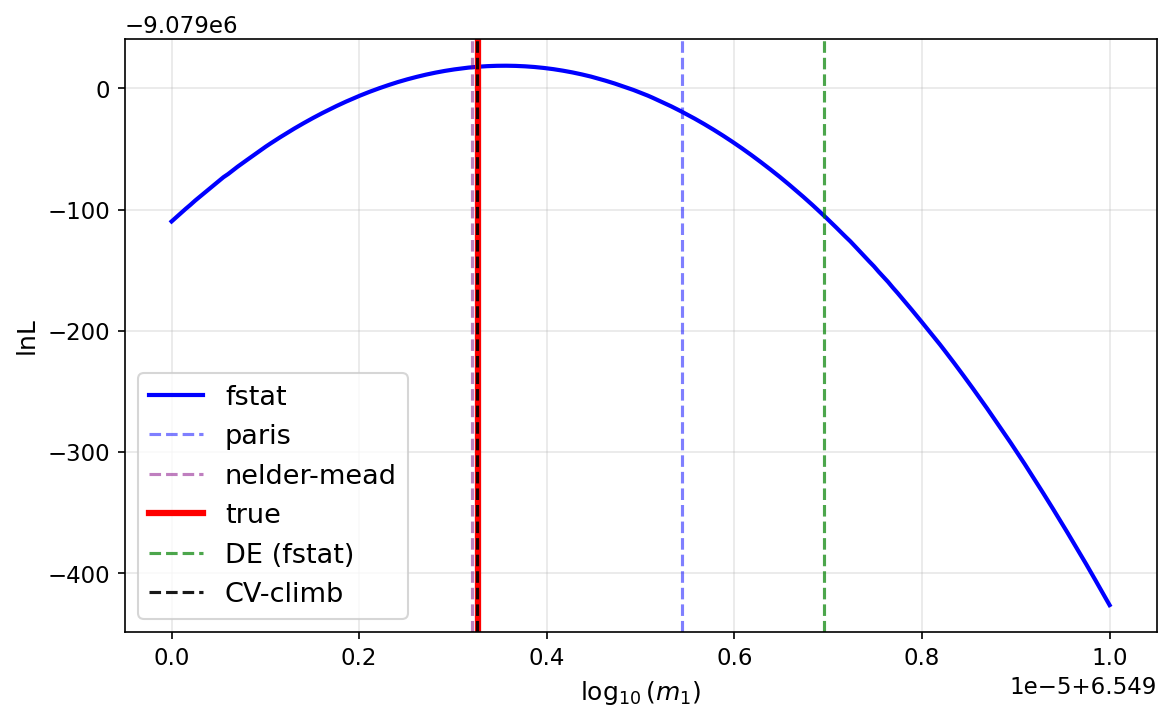

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], lnL_tm, '-', color='blue', linewidth=2, label='fstat')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='paris')
ax.axvline(maxld_pt2[0],         color='purple', linestyle='--', alpha=0.5, label='nelder-mead')
ax.axvline(param_true[0],        color='red',  linewidth=3, label='true')

ax.axvline(GLOBAL_MAP[0], color='green', linestyle='--', alpha=0.7, label='DE (fstat)')
ax.axvline(refined[0],    color='black', linestyle='--',  alpha=0.9, linewidth=1.5, label='CV-climb')

ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('lnL', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

In [27]:
def fstat_decompose(theta_template):
    """Same internals as loglike_obj.__call__, but returns the pieces
    (X_scalar, beta, chi_sq, penalty, f_stat) instead of just f_stat."""
    m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0 = theta_template

    selected = loglike_obj.mode_select if loglike_obj.mode_select else loglike_obj.selected_labels
    waveform_combined = loglike_obj._generate_selected_waveforms(theta_template, selected)

    h_temp = gwf.xp.array(waveform_response(
        m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_temp_fft = gwf.freq_wave(h_temp)

    mode_ffts = [gwf.freq_wave(waveform_combined[i]) for i in range(waveform_combined.shape[0])]

    rho_tot = gwf.xp.sqrt(gwf.inner(h_temp_fft, h_temp_fft))
    rho_m = gwf.xp.empty(len(mode_ffts), dtype=gwf.xp.float64)
    for idx, hf in enumerate(mode_ffts):
        rho_m[idx] = gwf.xp.sqrt(gwf.inner(hf, hf))

    rho_dom_M = rho_m[rho_m.argmax()]
    beta = gwf.calc_beta(rho_dom_M, rho_tot)

    X_scalar = float(gwf.inner(loglike_obj.signal_fft, h_temp_fft, return_complex=False)) / float(rho_tot)

    X_modes = gwf.xp.empty(len(mode_ffts), dtype=gwf.xp.float64)
    for idx, hf in enumerate(mode_ffts):
        X_modes[idx] = float(gwf.inner(loglike_obj.signal_fft, hf, return_complex=False)) / float(rho_m[idx])

    chi_sq = float(gwf.chi_sq(X_modes, rho_m))
    penalty = float(gwf.xp.exp(-0.5 * beta * chi_sq))
    f_stat = X_scalar * penalty

    return dict(X_scalar=float(X_scalar), beta=float(beta), chi_sq=chi_sq,
                penalty=penalty, f_stat=float(f_stat))

n_points = line_points_logm1.shape[1]
X_scalar_arr = np.zeros(n_points)
chi_sq_arr   = np.zeros(n_points)
fstat_arr    = np.zeros(n_points)

for i in range(n_points):
    logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = line_points_logm1[:, i]
    qS_i = np.arccos(cosqS_i)
    theta = [10**logm1, 10**logm2, a_i, p0_i, e0_i, xI0, dist, qS_i, phiS_i,
             qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    d = fstat_decompose(theta)
    X_scalar_arr[i] = d['X_scalar']
    chi_sq_arr[i]   = d['chi_sq']
    fstat_arr[i]    = d['f_stat']



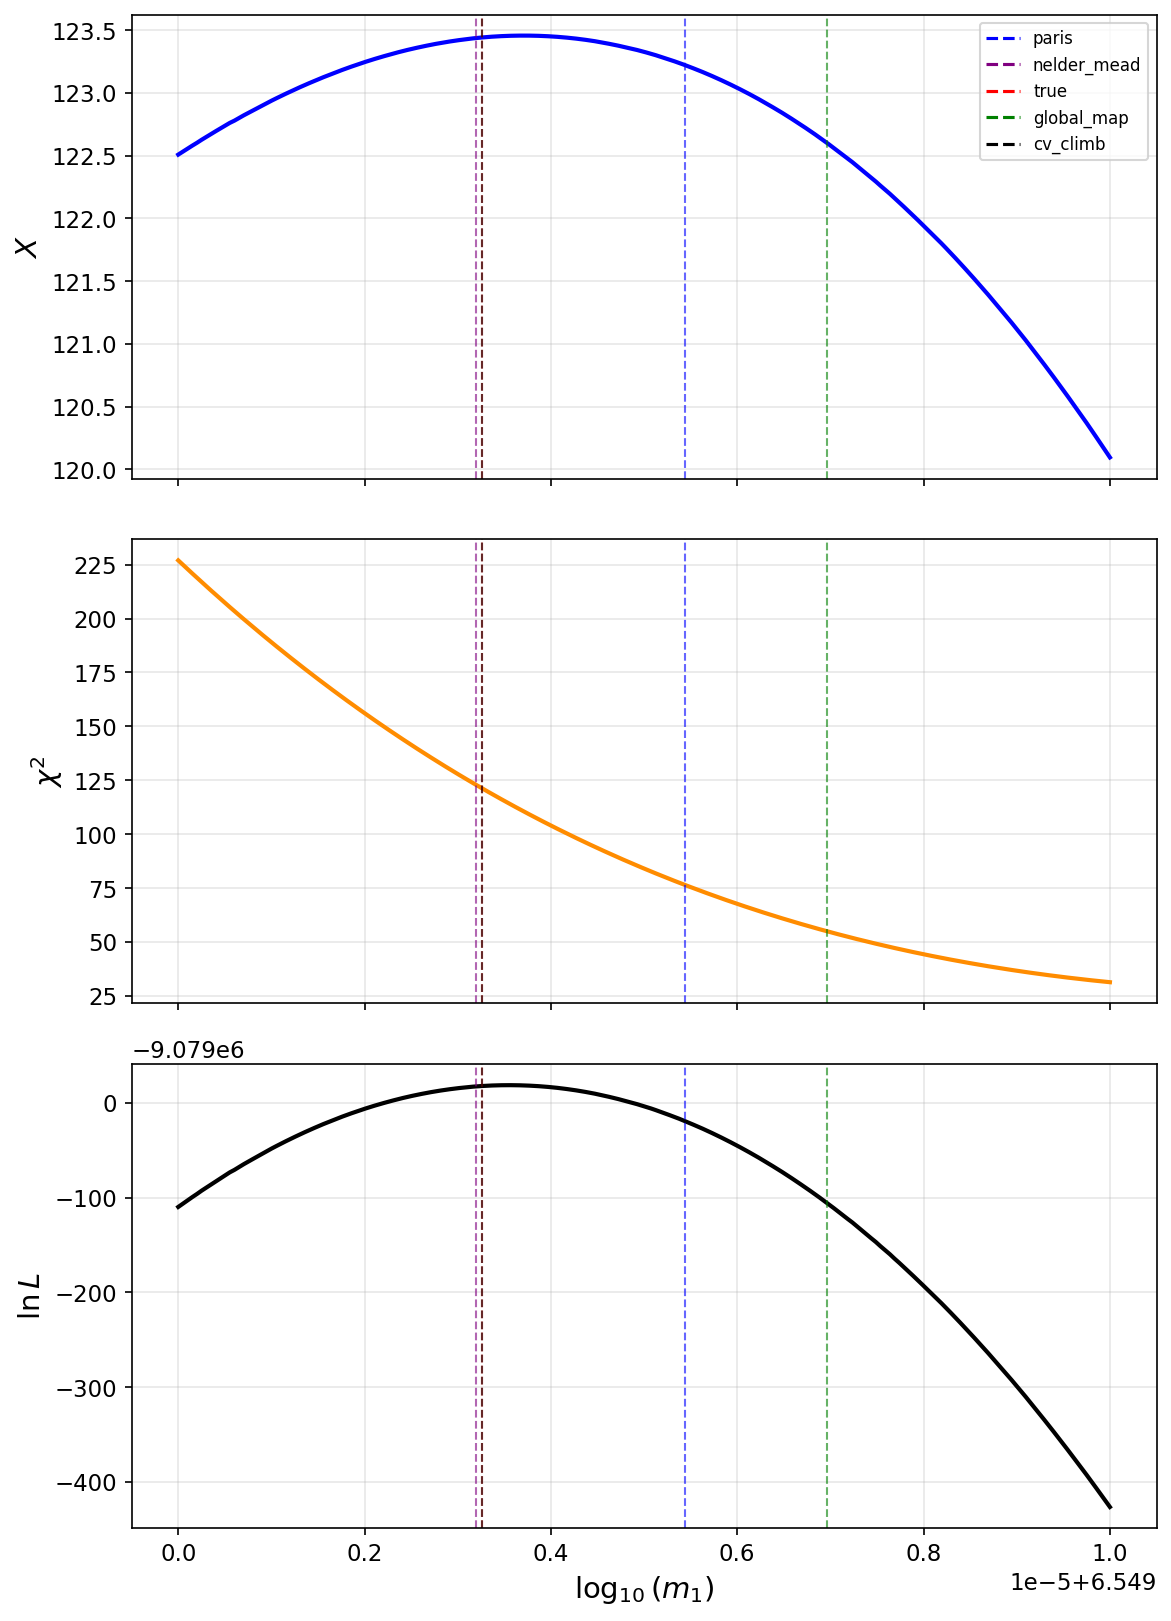

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(8, 11), sharex=True)

axes[0].plot(line_points_logm1[0], X_scalar_arr, color='blue', linewidth=2)
axes[0].set_ylabel(r'$X$')

axes[1].plot(line_points_logm1[0], chi_sq_arr, color='darkorange', linewidth=2)
axes[1].set_ylabel(r'$\chi^2$')

axes[2].plot(line_points_logm1[0], lnL_tm, color='black', linewidth=2)
axes[2].set_ylabel(r'$\ln L$')
axes[2].set_xlabel(r'$\log_{10}(m_1)$')

markers = dict(paris=(proc1_maxld_pt_1d[0], 'blue'), nelder_mead=(maxld_pt2[0], 'purple'),
               true=(param_true[0], 'red'), global_map=(GLOBAL_MAP[0], 'green'),
               cv_climb=(refined[0], 'black'))
for ax in axes:
    for label, (x, c) in markers.items():
        ax.axvline(x, color=c, linestyle='--', alpha=0.6, linewidth=1)
    ax.grid(alpha=0.3)

axes[0].legend([plt.Line2D([0],[0], color=c, ls='--') for _, c in markers.values()],
               list(markers.keys()), fontsize=8, loc='best')
plt.tight_layout()

In [30]:
lnL_tm

array([-9079426.48664747, -9079419.59756317, -9079412.72870149,
       -9079405.9660032 , -9079399.15368777, -9079392.43949647,
       -9079385.86100678, -9079379.23441423, -9079372.73287498,
       -9079366.2505848 , -9079359.8168382 , -9079353.43763604,
       -9079347.09585443, -9079340.81097358, -9079334.58560021,
       -9079328.43618803, -9079322.29338852, -9079316.23258442,
       -9079310.09667131, -9079304.15716979, -9079298.2875088 ,
       -9079292.41807454, -9079286.73260753, -9079281.02354977,
       -9079275.33214819, -9079269.66751989, -9079264.08355416,
       -9079258.57712062, -9079253.09478269, -9079247.6981406 ,
       -9079242.33357816, -9079237.03954788, -9079231.7727525 ,
       -9079226.57086777, -9079221.42796379, -9079216.3515475 ,
       -9079211.32029588, -9079206.48023497, -9079201.78477502,
       -9079196.87480781, -9079192.06184012, -9079187.28558768,
       -9079182.60195168, -9079177.97051654, -9079173.30449214,
       -9079168.75594519, -9079164.35672

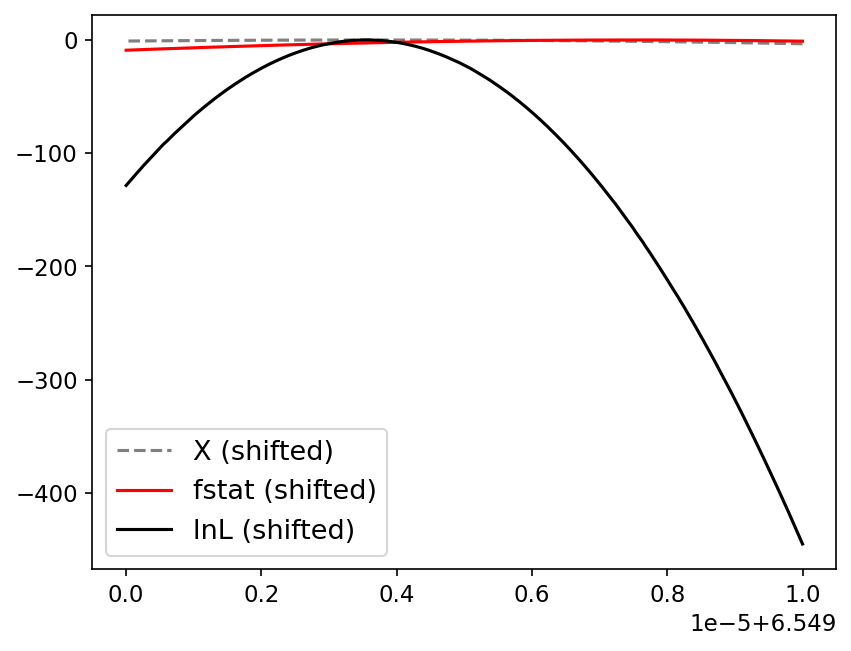

In [36]:
plt.plot(line_points_logm1[0], X_scalar_arr-np.max(X_scalar_arr), color='grey', linestyle='--', label='X (shifted)')
plt.plot(line_points_logm1[0], fstat_arr-np.max(fstat_arr), color='red', label='fstat (shifted)')
plt.plot(line_points_logm1[0], lnL_tm-np.max(lnL_tm), color='black', label='lnL (shifted)')
plt.legend()

plt.show()

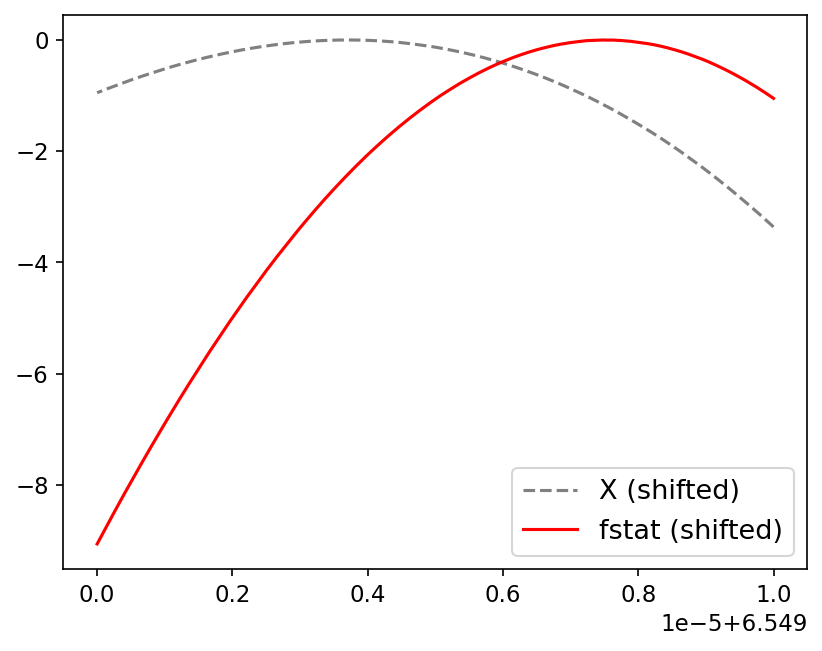

In [37]:
plt.plot(line_points_logm1[0], X_scalar_arr-np.max(X_scalar_arr), color='grey', linestyle='--', label='X (shifted)')
plt.plot(line_points_logm1[0], fstat_arr-np.max(fstat_arr), color='red', label='fstat (shifted)')
# plt.plot(line_points_logm1[0], lnL_tm-np.max(lnL_tm), color='black', label='lnL (shifted)')
plt.legend()

plt.show()

In [35]:
import numpy as np

def sky_antipode(qS, phiS):
    """
    Antipodal sky point: qS -> pi - qS, phiS -> phiS + pi (mod 2pi).
    qS: colatitude [rad], phiS: azimuth [rad].
    """
    qS_anti = np.pi - qS
    phiS_anti = (phiS + np.pi) % (2 * np.pi)
    return qS_anti, phiS_anti

# EMRI_C true values
qS_true, phiS_true = 2.0420, 5.7873
qS_anti, phiS_anti = sky_antipode(qS_true, phiS_true)

print(f"qS_true={qS_true:.4f}  phiS_true={phiS_true:.4f}  cos(qS_true)={np.cos(qS_true):.5f}")
print(f"qS_anti={qS_anti:.4f}  phiS_anti={phiS_anti:.4f}  cos(qS_anti)={np.cos(qS_anti):.5f}")


qS_true=2.0420  phiS_true=5.7873  cos(qS_true)=-0.45396
qS_anti=1.0996  phiS_anti=2.6457  cos(qS_anti)=0.45396


In [36]:
maxld_pt1

array([ 6.54900544,  1.90363192,  0.95000233,  7.38897171,  0.31600117,
       -0.4695093 ,  5.80237301])

In [37]:
import numpy as np

def loglikelihood(params_row):
    """params_row: [log10(m1), log10(m2), a, p0, e0, cos(qS), phiS].
    Standard Gaussian log-likelihood, up to a theta-independent additive constant:
        lnL(theta) = -0.5 * <d - h(theta) | d - h(theta)>
    Uses loglike_obj.signal_fft (the seed=42 noisy data already built above) and
    the full (unrestricted-mode) waveform -- no mode selection, no f-stat penalty.
    """
    logm1, logm2, a, p0, e0, cosqS, phiS = params_row
    qS = np.arccos(cosqS)
    theta = [10**logm1, 10**logm2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
             Phi_phi0, Phi_theta0, Phi_r0]
    h = gwf.xp.array(waveform_response(*theta, T=T, dt=dt))
    h_fft = gwf.freq_wave(h)
    r_fft = loglike_obj.signal_fft - h_fft
    chi2 = float(gwf.inner(r_fft, r_fft))
    return -0.5 * chi2

# --- compare f-stat vs true log-likelihood on the same candidates ---
candidates = {
    "true (param_true)":                np.asarray(param_true).ravel(),
    "maxld_pt1 (raw MCMC top sample)":  np.asarray(maxld_pt1).ravel(),
    "maxld_pt2 (NM optimizer MAP)":     np.asarray(maxld_pt2).ravel(),
    "line-scan argmax":                 np.array([6.54900749, 1.90363137, 0.95000452,
                                                    7.38894506, 0.31600226, -0.48415786, 5.81657206]),
}

print(f"{'candidate':34s} {'f_stat':>12s} {'lnL':>16s}")
for label, pt in candidates.items():
    print(f"{label:34s} {lnL(pt):12.4f} {loglikelihood(pt):16.4f}")


candidate                                f_stat              lnL


NameError: name 'lnL' is not defined

In [40]:
loglikelihood(maxld_pt1)

-9079019.107869359

In [41]:
loglikelihood(maxld_pt2)

-9079008.814740505

In [33]:
h_true_fft = gwf.freq_wave(gwf.xp.array(waveform_response(*params_star, T=T, dt=dt)))
def loglikelihood_ratio(params_row):
    """ln Lambda(theta) = <d|h(theta)> - 0.5*<h(theta)|h(theta)>, against
    the noisy data (loglike_obj.signal_fft, seed=42 already loaded above)."""
    logm1, logm2, a, p0, e0, cosqS, phiS = params_row
    qS = np.arccos(cosqS)
    theta = [10**logm1, 10**logm2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
            Phi_phi0, Phi_theta0, Phi_r0]
    h = gwf.xp.array(waveform_response(*theta, T=T, dt=dt))
    h_fft = gwf.freq_wave(h)
    d_dot_h = float(gwf.inner(loglike_obj.signal_fft, h_fft, return_complex=False))
    h_dot_h = float(gwf.inner(h_fft, h_fft))
    return d_dot_h - 0.5 * h_dot_h

def loglikelihood_ratio_noiseless(params_row):
    """Same as loglikelihood_ratio, but against the CLEAN injected signal --
    isolates the purely deterministic model-mismatch part, with no noise
    fluctuation. Peaks EXACTLY at rho^2/2 at theta_true (no noise to perturb
    that), unlike the noisy version which only peaks near there.
    """
    logm1, logm2, a, p0, e0, cosqS, phiS = params_row
    qS = np.arccos(cosqS)
    theta = [10**logm1, 10**logm2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
             Phi_phi0, Phi_theta0, Phi_r0]
    h = gwf.xp.array(waveform_response(*theta, T=T, dt=dt))
    h_fft = gwf.freq_wave(h)
    d_dot_h = float(gwf.inner(h_true_fft, h_fft, return_complex=False))
    h_dot_h = float(gwf.inner(h_fft, h_fft))
    return d_dot_h - 0.5 * h_dot_h

print(f"{'candidate':34s} {'lnLambda (noisy)':>18s} {'lnLambda (noiseless)':>22s} {'noise contrib':>14s}")
for label, pt in candidates.items():
    ln_noisy = loglikelihood_ratio(pt)
    ln_clean = loglikelihood_ratio_noiseless(pt)
    print(f"{label:34s} {ln_noisy:18.4f} {ln_clean:22.4f} {ln_noisy - ln_clean:14.4f}")

candidate                            lnLambda (noisy)   lnLambda (noiseless)  noise contrib


NameError: name 'candidates' is not defined